The coupling layer divide the data point in 2 parts, one is not modified and the second part is modifified by a function of the first part.
The autoregressive flow instead modify each component od the data point with a function of the previous components.
In this way the jacobian is still triangular.

In [423]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import random

In [424]:
def mu1(z): return 0.0
def sigma1(z): return 1.0 
# WE ARE NOT CHANGING X1!!

def mu2(x1): return jnp.sin(x1**2 + 0.5 * x1)
def sigma2(x1): return jnp.exp(0.01 * x1)

def mu3(x1, x2): return 0.1*x1 + 0.1*x2
def sigma3(x1, x2): return jnp.exp(0.01 * (x1 - x2))

In [425]:
def au_forward(z):
    z1, z2, z3 = z[:,0], z[:,1], z[:,2]

    x1 = mu1(z1) + sigma1(z1) * z1
    x2 = mu2(x1) + sigma2(x1) * z2
    x3 = mu3(x1, x2) + sigma3(x1, x2) * z3

    return jnp.stack([x1, x2, x3], axis=1)

def au_inverse(x):
    x1, x2, x3 = x[:,0], x[:,1], x[:,2]

    z1 = (x1 - mu1(x1)) / sigma1(x1)
    z2 = (x2 - mu2(x1)) / sigma2(x1)
    z3 = (x3 - mu3(x1, x2)) / sigma3(x1, x2)

    return jnp.stack([z1, z2, z3], axis=1)

In [426]:
def log_pz(z):
    return -0.5 * jnp.sum(z**2, axis=-1) - (z.shape[-1] / 2) * jnp.log(2 * jnp.pi)
# multivariate standard normal distribution

def log_px(x):
    x1, x2, x3 = x[:,0], x[:,1], x[:,2]

    z = au_inverse(x)
    
    log_det_jacobian = jnp.log(sigma1(x1)) + jnp.log(sigma2(x1)) + jnp.log(sigma3(x1, x2))
    return log_pz(z) - log_det_jacobian
# is usefull only for the first flow, for the others we need to compute the log determinant of the jacobian of the transformation

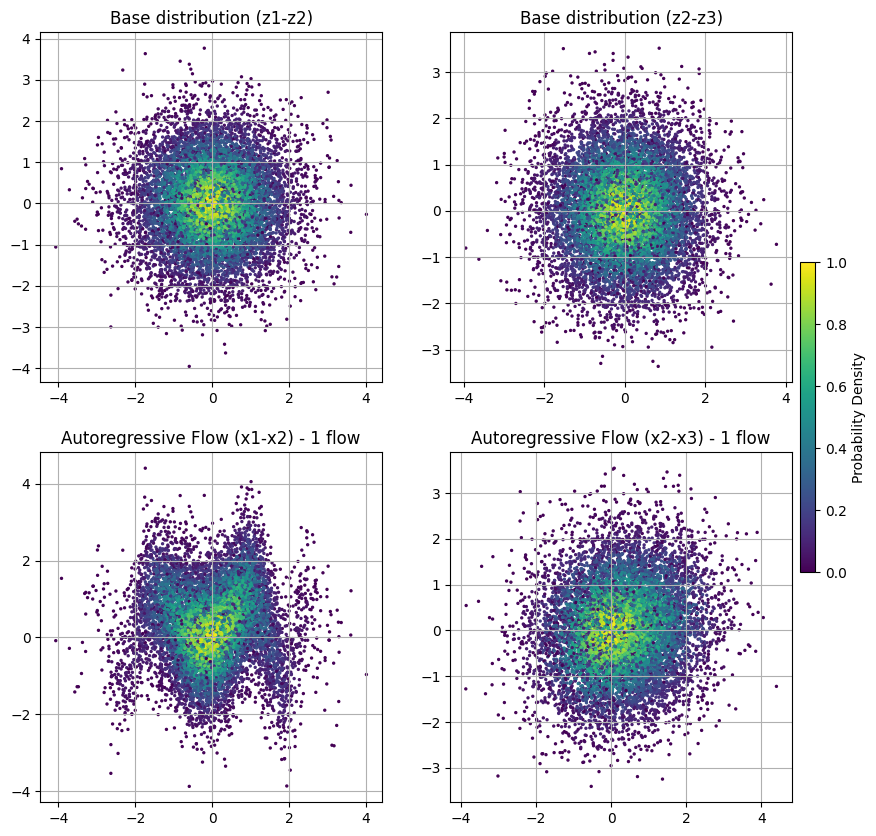

In [427]:
key = random.PRNGKey(0)
n_samples = 10000
z = random.normal(key, (n_samples, 3))
log_pz_values = log_pz(z)
pz = jnp.exp(log_pz_values)

x = au_forward(z)
log_px_values = log_px(x)
px = jnp.exp(log_px_values)


# plotting base and first flow with probability 
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.scatter(z[:,0], z[:,1], s=2, c=pz, cmap='viridis')
plt.title("Base distribution (z1-z2)")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.scatter(z[:,1], z[:,2], s=2, c=pz, cmap='viridis')
plt.title("Base distribution (z2-z3)")
plt.grid(True)

plt.subplot(2, 2, 3)
plt.scatter(x[:,0], x[:,1], s=2, c=px, cmap='viridis')
plt.title("Autoregressive Flow (x1-x2) - 1 flow")
plt.grid(True)

plt.subplot(2, 2, 4)
plt.scatter(x[:,1], x[:,2], s=2, c=px, cmap='viridis')
plt.title("Autoregressive Flow (x2-x3) - 1 flow")
plt.grid(True)

cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=plt.gcf().get_axes(), orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('Probability Density')
plt.show()

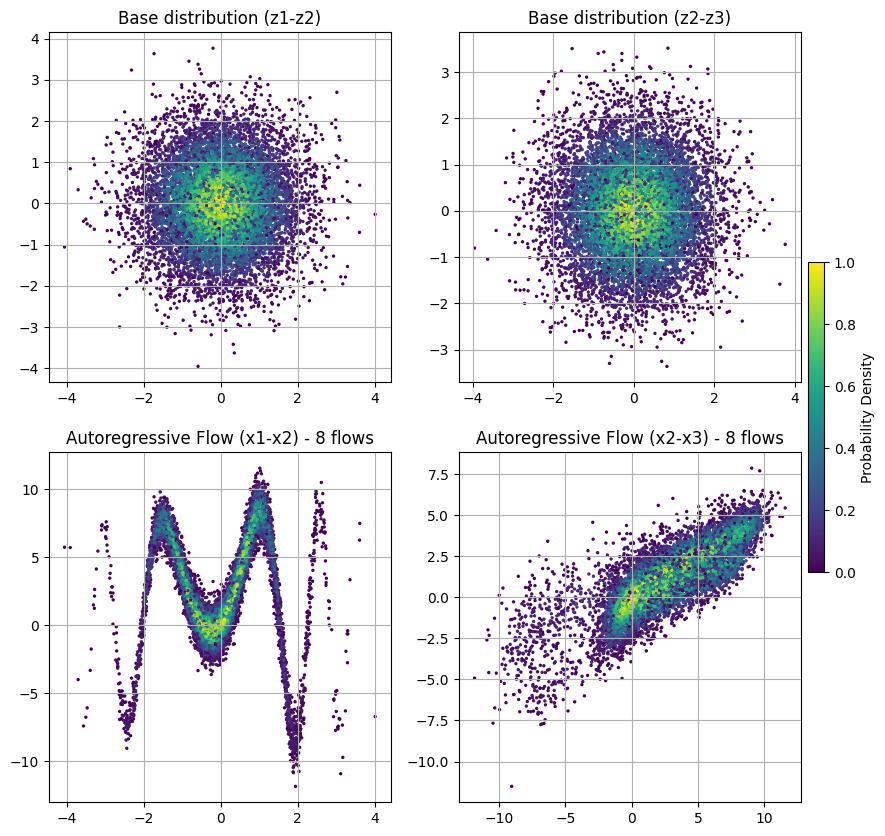

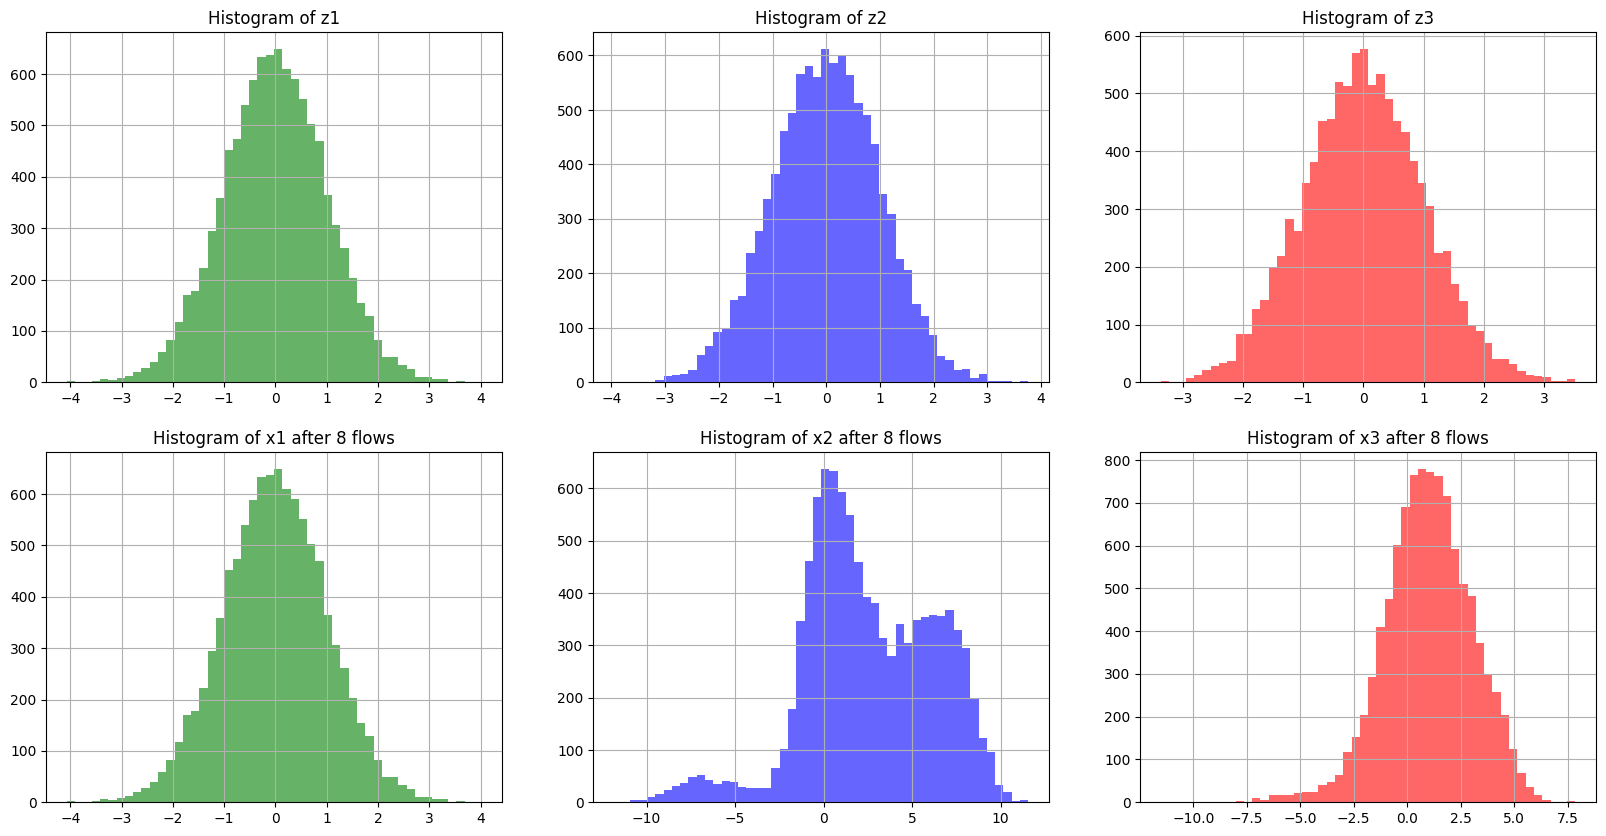

In [428]:
key = random.PRNGKey(0)
z = random.normal(key, (n_samples, 3))
log_pz_values = log_pz(z)
pz = jnp.exp(log_pz_values)
n_flows = 8
log_prob = log_pz(z)
x = z.copy()
for _ in range(n_flows):
    x1, x2, x3 = x[:,0], x[:,1], x[:,2]
    log_det = (jnp.log(sigma1(x1)) +
               jnp.log(sigma2(x1)) +
               jnp.log(sigma3(x1, x2)))
    log_prob = log_prob - log_det
    x = au_forward(x)

px = jnp.exp(log_prob)

# plotting base and first flow with probability
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.scatter(z[:,0], z[:,1], s=2, c=pz, cmap='viridis')
plt.title("Base distribution (z1-z2)")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.scatter(z[:,1], z[:,2], s=2, c=pz, cmap='viridis')
plt.title("Base distribution (z2-z3)")
plt.grid(True)

plt.subplot(2, 2, 3)
plt.scatter(x[:,0], x[:,1], s=2, c=px, cmap='viridis')
plt.title(f"Autoregressive Flow (x1-x2) - {n_flows} flows")
plt.grid(True)

plt.subplot(2, 2, 4)
plt.scatter(x[:,1], x[:,2], s=2, c=px, cmap='viridis')
plt.title(f"Autoregressive Flow (x2-x3) - {n_flows} flows")
plt.grid(True)

cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=plt.gcf().get_axes(), orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('Probability Density')
plt.show()

#histogram of the samplesbefore and after n flows
plt.figure(figsize=(20, 10))
plt.subplot(2, 3, 1)
plt.hist(z[:,0], bins=50, density=False, alpha=0.6, color='g')
plt.title("Histogram of z1")
plt.grid(True)
plt.subplot(2, 3, 2)
plt.hist(z[:,1], bins=50, density=False, alpha=0.6, color='b')
plt.title("Histogram of z2")
plt.grid(True)
plt.subplot(2, 3, 3)
plt.hist(z[:,2], bins=50, density=False, alpha=0.6, color='r')
plt.title("Histogram of z3")
plt.grid(True)
plt.subplot(2, 3, 4)
plt.hist(x[:,0], bins=50, density=False, alpha=0.6, color='g')
plt.title(f"Histogram of x1 after {n_flows} flows")
plt.grid(True)
plt.subplot(2, 3, 5)
plt.hist(x[:,1], bins=50, density=False, alpha=0.6, color='b')
plt.title(f"Histogram of x2 after {n_flows} flows")
plt.grid(True)
plt.subplot(2, 3, 6)
plt.hist(x[:,2], bins=50, density=False, alpha=0.6, color='r')
plt.title(f"Histogram of x3 after {n_flows} flows")
plt.grid(True)  